In [1]:
import numpy as np
import numpy.linalg as mat, scipy.linalg as smat
import matplotlib.pyplot as plt
import sys
import json
from scvxplot import *


# Loading Sample Data

In [2]:
with open('sampledata.json', 'r') as file: jsondata = json.load(file)
ind1 = 3; ind2 = 1;
tag1 = list(jsondata)[ind1];
print(list(jsondata['params'])); #print('')
print(list(jsondata['I'][-1])); #print('')
print(jsondata['I'][-1]['iter_num']); #print('')
print(type(np.array(jsondata['O'][-1]['dz_s'])))
tags = ['dz_s', 'du_s', 'dt_val', 'zs', 'us', 'dts', 'ts', 'zs_ref', 'us_ref', 'dts_ref', 'ts_ref','zs_minus', 'Ak', 'Bk', 'Bkp', 'Sk']
othertags = ['weights','weights_ref','cost','Ts','conv_data','solve_time', 'parse_time', 'prop_time', 'cnst_path', 'converged', 'iter_num']
# tags = list(jsondata['O'][-1])

['bools', 'n', 'm', 'path_lim', 'path_idx', 'n_path', 'nfz_idx', 'n_nfz', 'aux_idx', 'n_aux', 'n_ineq', 'n_eq', 'cost_name', 'zi', 'zi_idx', 'zi_min', 'zi_min_idx', 'zi_max', 'zi_max_idx', 'n_init', 'n_init_ineq', 'zf', 'zf_idx', 'zf_min', 'zf_min_idx', 'zf_max', 'zf_max_idx', 'n_term', 'n_term_ineq', 'z_min', 'z_min_idx', 'z_max', 'z_max_idx', 'n_state', 'u_min', 'u_min_idx', 'u_max', 'u_max_idx', 'udot_max', 'udot_max_idx', 'n_ctrl', 'n_udot', 'weights', 'n_dyn', 'conv', 'mission', 'N', 'solver_opts', 'case_flag', 'ge', 'T_init', 'obs', 'mass', 'theta_max', 'nondim', 'z0s', 'ui', 'uf', 'u_norm_min', 'u_norm_max', 'ddts_max', 'dts_min', 'dts_max', 'nz', 'n_plus', 'n_minus', 'Npm', 'eps_ctcs', 'z_ind', 'Ak_ind', 'Bk_ind', 'Bkp_ind', 'Sk_ind', 'Ak', 'Bk', 'Bkp', 'Sk', 'lds0', 'N_dens', 'conv_data', 'dt_init', 'Ts_init', 'dts_init', 'z_waypt', 'ts_init', 'zs_init', 'us_init', 'save_var_names']
['iter_num', 'zs_ref', 'us_ref', 'dts_ref', 'ts_ref', 'conv_data', 'weights', 'Ts_ref']
2
<clas

# EXAMPLE 1

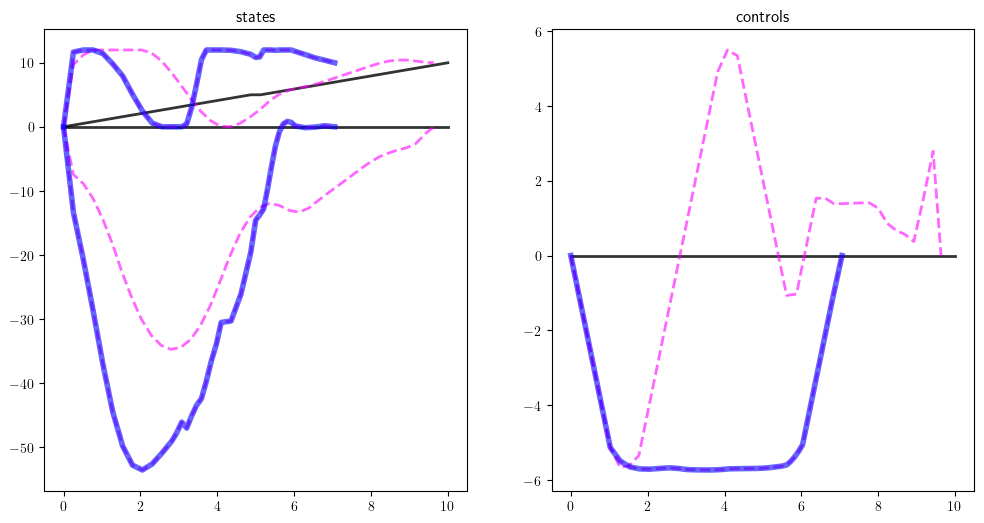

In [3]:
tags = ['dz_s', 'du_s', 'dt_val', 'zs', 'us', 'dts', 'ts', 'zs_ref', 'us_ref', 'dts_ref', 'ts_ref','zs_minus', 'Ak', 'Bk', 'Bkp', 'Sk']
fig,axs = plt.subplots(1,2,figsize=(12,6))
PLOTS2 = SCVXPLOT();

params0 = {}; params1 = {}; params2 = {};
params0['title'] = 'states'; params1['title'] = 'controls'; params2['title'] = 'something3'
PLOTS2.axParams(axs[0],params0); PLOTS2.axParams(axs[1],params1); 

figdata = {}; ins = {};
ins['data'] = jsondata; ins['figdata'] = figdata
ins['tags'] = tags;
# TODO - remove and have it go to Python after I reformat the data
ins['matrix_style'] = 'matlab'


##########################################################################################
PENS = {};
PENS['init'] = {'lrgba':[0,0,0,0.8],'frgba':[0,0,0,0.8],'lw':2,'lsty':'-'};
PENS['iters'] = {'lrgba':[1,0,1,0.6],'frgba':[1,0,0,0.2],'lw':2,'lsty':'--'};
PENS['opt'] = {'lrgba':[0,0,1,0.6],'frgba':[1,0,0,0.2],'lw':4,'lsty':'-'};

showtags = {}
showtags['opt'] = True;
showtags['init'] = True;
showtags['iters'] = True;

sparams = {}; sparams['tag'] = 'zs'; sparams['ttag'] = 'ts'; sparams['inds'] = [1,3]
uparams = {}; uparams['tag'] = 'us'; uparams['ttag'] = 'ts'; uparams['inds'] = [0]
##########################################################################################

PLOTS2.loadData(ins=ins,version='skye');
PLOTS2.addLayerStyles(PENS)

sparams['showtags'] = showtags;
uparams['showtags'] = showtags;

PLOTS2.plotOpt(axs[0],ins=sparams);
PLOTS2.plotOpt(axs[1],ins=uparams);


# states  - initialization, iterations, converged



# EXAMPLE BASIC

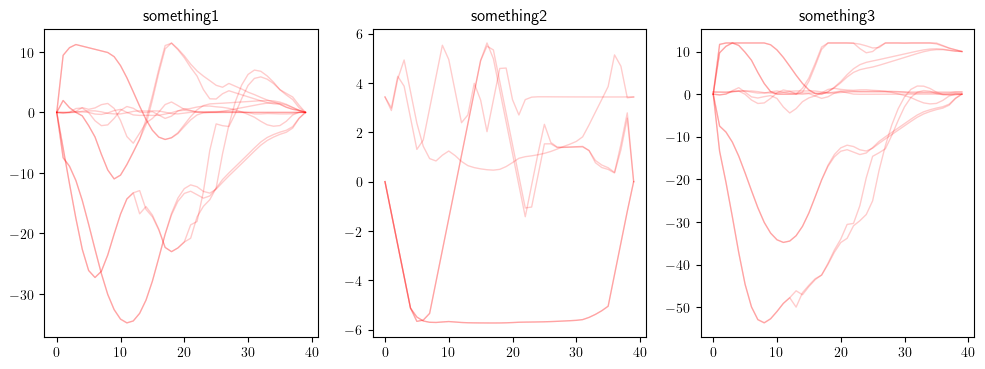

In [4]:
tags = ['dz_s', 'du_s', 'dt_val', 'zs', 'us', 'dts', 'ts', 'zs_ref', 'us_ref', 'dts_ref', 'ts_ref','zs_minus', 'Ak', 'Bk', 'Bkp', 'Sk']
fig,axs = plt.subplots(1,3,figsize=(12,4))
PLOTS1 = SCVXPLOT();

params0 = {}; params1 = {}; params2 = {};
params0['title'] = 'something1'
params1['title'] = 'something2'
params2['title'] = 'something3'

PLOTS1.axParams(axs[0],params0);
PLOTS1.axParams(axs[1],params1);
PLOTS1.axParams(axs[2],params2);
# 
figdata = {}; ins = {};
ins['data'] = jsondata; ins['figdata'] = figdata
# ins['state_locs'] = {'state1':0,'state2':1,'state3':2,'state4':3};
ins['tags'] = tags;

PENS = {};
PENS['states1'] = {'lrgba':[1,0,0,0.2]}

PLOTS1.loadData(ins=ins,version='skye');
PLOTS1.addLayerStyles(PENS);
params1 = {}; params1['itrs'] = [0,1,2,3,4]; params1['tags'] = ['dz_s']; params1['ttags'] = ['ts']; params1['layer'] = 'states1'; params1['matrix_style'] = 'matlab';
params2 = {}; params2['itrs'] = [0,1,2,3,4]; params2['tags'] = ['us']; params2['ttags'] = ['ts']; params2['layer'] = 'states1'; params2['matrix_style'] = 'matlab';
params3 = {}; params3['itrs'] = [0,1,2,3,4]; params3['tags'] = ['zs']; params3['ttags'] = ['ts']; params3['layer'] = 'states1'; params3['matrix_style'] = 'matlab';
# params1['curve_type'] = 'by_time'; params2['curve_type'] = 'by_time'; params3['curve_type'] = 'by_time';
PLOTS1.plotCurves(axs[0],ins=params1);
PLOTS1.plotCurves(axs[1],ins=params2);
PLOTS1.plotCurves(axs[2],ins=params3);
